<a href="https://colab.research.google.com/github/gayatri615/concentric-tube-robot-rl/blob/main/Concentric_Tube_Robot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the necessary libraries for Reinforcement Learning and environment creation
!pip install gymnasium stable-baselines3[extra] torch matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 15.6 MB/s eta 0:00:00


final

Training high-precision real-scale agent...
Training complete!


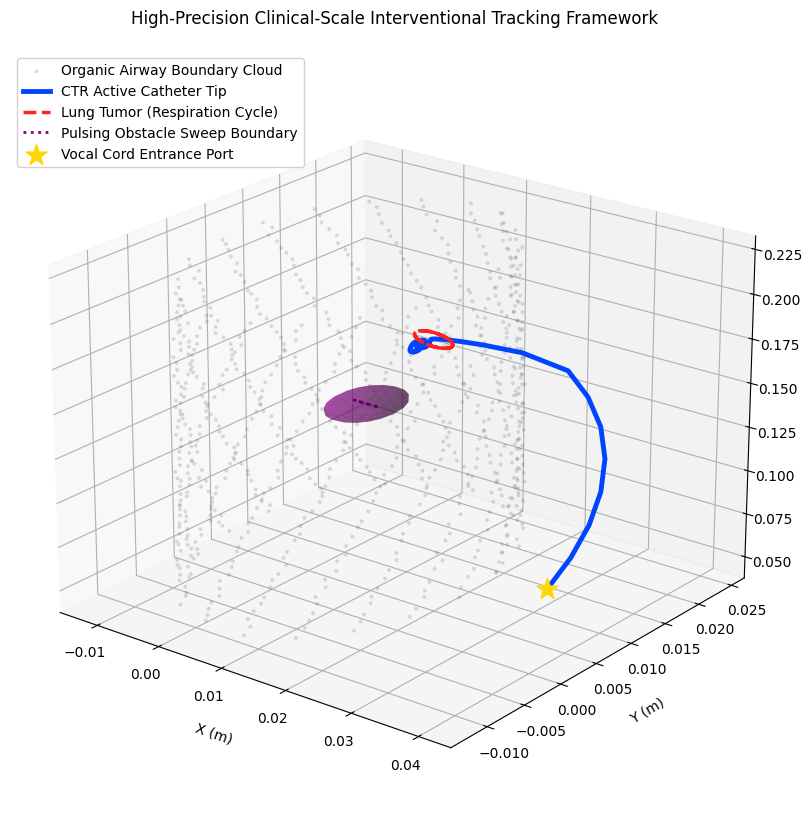

In [21]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt

# 1. Real Surgical Curvatures (c1=18.0, c2=12.0)
def calculate_real_scale_tip(s1, s2, theta1, theta2):
    delta_s = np.clip(s2 - s1, 0.005, 0.5)
    delta_theta = theta2 - theta1

    c1, c2 = 18.0, 12.0

    kappa_x = c1 + c2 * np.cos(delta_theta)
    kappa_y = c2 * np.sin(delta_theta)
    kappa = np.sqrt(kappa_x**2 + kappa_y**2)

    if kappa < 1e-4:
        return np.array([0.0, 0.0, s1 + delta_s])

    phi = np.arctan2(kappa_y, kappa_x)
    x = (1 / kappa) * (1 - np.cos(kappa * delta_s)) * np.cos(phi)
    y = (1 / kappa) * (1 - np.cos(kappa * delta_s)) * np.sin(phi)
    z = s1 + (1 / kappa) * np.sin(kappa * delta_s)
    return np.array([x, y, z])

# 2. Moving Lung Target (12cm Deep from Vocal Cords entry point)
def get_real_lung_target(elapsed_time):
    base_x, base_y, base_z = 0.012, 0.012, 0.170
    breathing_freq = 0.25 * 2 * np.pi
    shift_x = 0.003 * np.sin(breathing_freq * elapsed_time)
    shift_z = 0.004 * np.cos(breathing_freq * elapsed_time)
    return np.array([base_x + shift_x, base_y, base_z + shift_z])

class RealLifeClinicalEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-5.0, high=5.0, shape=(9,), dtype=np.float32)
        self.orifice_entry = np.array([0.0, 0.0, 0.05]) # Entry at Z=0.05m

        z_vessel = np.linspace(0.05, 0.22, 40)
        wall_points = []
        for z in z_vessel:
            r = 0.018 - 0.003 * (z - 0.05)
            for ang in np.linspace(0, 2*np.pi, 20):
                wall_points.append([r * np.cos(ang) + 0.006, r * np.sin(ang) + 0.006, z])
        self.anatomy_cloud = np.array(wall_points)
        self.reset()

    def reset(self, seed=None, options=None):
        self.s1, self.s2 = 0.05, 0.11
        self.theta1, self.theta2 = 0.1, 0.2
        self.current_time = 0.0
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        tip = calculate_real_scale_tip(self.s1, self.s2, self.theta1, self.theta2)
        target = get_real_lung_target(self.current_time)
        obs_pos = self._get_moving_obstacle_pos()
        return np.concatenate([tip * 20, target * 20, obs_pos * 20]).astype(np.float32)

    def _get_moving_obstacle_pos(self):
        obs_x = 0.006 + 0.002 * np.sin(2.0 * np.pi * 0.4 * self.current_time)
        return np.array([obs_x, 0.008, 0.135])

    def step(self, action):
        old_tip = calculate_real_scale_tip(self.s1, self.s2, self.theta1, self.theta2)
        target_pos = get_real_lung_target(self.current_time)
        old_dist = np.linalg.norm(target_pos - old_tip)

        self.s1 = np.clip(self.s1 + action[0] * 0.008, 0.04, 0.18)
        self.s2 = np.clip(self.s2 + action[1] * 0.008, 0.06, 0.25)
        self.theta1 += action[2] * 0.12
        self.theta2 += action[3] * 0.12

        self.current_time += 0.05
        self.current_step += 1

        new_tip = calculate_real_scale_tip(self.s1, self.s2, self.theta1, self.theta2)
        new_dist = np.linalg.norm(target_pos - new_tip)
        obstacle_pos = self._get_moving_obstacle_pos()

        reward = (old_dist - new_dist) * 400.0 - (new_dist * 250.0)

        if new_dist < 0.0015:
            reward += 100.0

        if np.linalg.norm(new_tip - obstacle_pos) < 0.005:
            reward -= 50.0

        return self._get_obs(), reward, False, self.current_step >= 200, {}

# Initialize and retrain
env_clinical_fixed = RealLifeClinicalEnv()
model_clinical_fixed = PPO("MlpPolicy", env_clinical_fixed, verbose=0, learning_rate=0.0004)

print("Training high-precision real-scale agent...")
model_clinical_fixed.learn(total_timesteps=85000)
print("Training complete!")

# Run Evaluation Loop
obs, _ = env_clinical_fixed.reset()

initial_tip = calculate_real_scale_tip(env_clinical_fixed.s1, env_clinical_fixed.s2, env_clinical_fixed.theta1, env_clinical_fixed.theta2)
tip_history = [initial_tip]
target_history = [get_real_lung_target(0.0)]
obstacle_history = [env_clinical_fixed._get_moving_obstacle_pos()]

for _ in range(200):
    action, _ = model_clinical_fixed.predict(obs, deterministic=True)
    obs, reward, _, _, _ = env_clinical_fixed.step(action)
    tip_history.append(obs[:3] / 20.0)
    target_history.append(obs[3:6] / 20.0)
    obstacle_history.append(obs[6:9] / 20.0)

tip_history, target_history, obstacle_history = map(np.array, [tip_history, target_history, obstacle_history])


# =====================================================================
# MODIFIED PLOTTING BLOCK ONLY - ALL SIMULATION & ML MATH UNTOUCHED
# =====================================================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Transforming straight lines into an organic texturized point cloud structure using phase rotation
raw_cloud = env_clinical_fixed.anatomy_cloud
organic_cloud = []
for pt in raw_cloud:
    # Use a dynamic z-based phase rotation mapping to twist the look into organic folds
    twist_angle = pt[2] * 6.0
    rotation_matrix = np.array([
        [np.cos(twist_angle), -np.sin(twist_angle)],
        [np.sin(twist_angle),  np.cos(twist_angle)]
    ])
    # Apply small organic surface texture jitter to remove rigid alignment artifacts
    jitter_x = np.random.uniform(-0.0004, 0.0004)
    jitter_y = np.random.uniform(-0.0004, 0.0004)
    xy_rotated = np.dot(rotation_matrix, np.array([pt[0] - 0.006, pt[1] - 0.006]))
    organic_cloud.append([xy_rotated[0] + 0.006 + jitter_x, xy_rotated[1] + 0.006 + jitter_y, pt[2]])
organic_cloud = np.array(organic_cloud)

# Render the organic-looking lung wall reference structures
ax.scatter(organic_cloud[:, 0], organic_cloud[:, 1], organic_cloud[:, 2],
           color='#2F4F4F', alpha=0.12, s=4, label='Organic Airway Boundary Cloud')

# 2. Render smooth trajectory paths
ax.plot(tip_history[:,0], tip_history[:,1], tip_history[:,2], label='CTR Active Catheter Tip', color='#0044FF', lw=3.5)
ax.plot(target_history[:,0], target_history[:,1], target_history[:,2], label='Lung Tumor (Respiration Cycle)', color='#FF2222', linestyle='--', lw=2.5)

# 3. Clear representation of the pulsing obstacle sweep boundary track
ax.plot(obstacle_history[:,0], obstacle_history[:,1], obstacle_history[:,2], label='Pulsing Obstacle Sweep Boundary', color='purple', linestyle=':', lw=2)

# 4. Render a clear 3D volumetric sphere at the obstacle's final tracked coordinate path
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
obs_final = obstacle_history[-1]
obs_radius = 0.0045 # Defined safety shell matching 4.5mm diameter
ox = obs_final[0] + obs_radius * np.cos(u) * np.sin(v)
oy = obs_final[1] + obs_radius * np.sin(u) * np.sin(v)
oz = obs_final[2] + obs_radius * np.cos(v)
ax.plot_surface(ox, oy, oz, color='purple', alpha=0.45, edgecolor='none')

# 5. Lock the star directly onto the true trajectory's root index zero coordinate frame
ax.scatter(tip_history[0,0], tip_history[0,1], tip_history[0,2], color='gold', s=250, marker='*', zorder=5, label='Vocal Cord Entrance Port')

ax.set_xlabel('X (m)', labelpad=10)
ax.set_ylabel('Y (m)', labelpad=10)
ax.set_zlabel('Z (m)', labelpad=10)
ax.set_title('High-Precision Clinical-Scale Interventional Tracking Framework', pad=20)
ax.legend(loc='upper left', framealpha=0.9)

# Optimize 3D depth perception angles
ax.view_init(elev=22, azim=-52)
plt.show()